# Copula Dependence Model Fitting & Evaluation

Fits Independence, Gaussian, and t-copula models to 48-period daily DA electricity price PITs.
Evaluates via rolling OOS log-likelihood, scenario coverage, event Brier scores, and tail dependence diagnostics.

## Section 0: Imports & Setup

In [10]:
import os
import warnings
warnings.filterwarnings('ignore')

# Ensure CWD is project root (handles both nbconvert and interactive runs)
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy.stats import norm, t as t_dist, spearmanr
from scipy.special import gammaln
from scipy.optimize import minimize_scalar

np.random.seed(42)
rng = np.random.default_rng(42)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

print('Imports OK')

Imports OK


## Section 1: Load & Validate Data

In [11]:
U_matrix = pd.read_parquet('data/processed/copula_U_matrix.parquet')
Z_gauss  = pd.read_parquet('data/processed/copula_Z_gauss.parquet')
lgbm_q   = pd.read_parquet('data/processed/lightgbm_quantile.parquet')

# Normalise column types to int
U_matrix.columns = [int(c) for c in U_matrix.columns]
Z_gauss.columns  = [int(c) for c in Z_gauss.columns]

# Validate shapes
assert U_matrix.shape == (727, 48), f"Unexpected U shape: {U_matrix.shape}"
assert Z_gauss.shape  == (727, 48), f"Unexpected Z shape: {Z_gauss.shape}"
assert list(U_matrix.columns) == list(range(1, 49))
assert U_matrix.isna().sum().sum() == 0, "NaNs in U_matrix"
assert Z_gauss.isna().sum().sum()  == 0, "NaNs in Z_gauss"
assert (U_matrix.values > 0).all() and (U_matrix.values < 1).all(), "U not in (0,1)"

print(f"U_matrix: {U_matrix.shape}  {U_matrix.index[0].date()} → {U_matrix.index[-1].date()}")
print(f"Z_gauss:  {Z_gauss.shape}")
print(f"lgbm_q:   {lgbm_q.shape}  cols: {lgbm_q.columns.tolist()}")
print(f"lgbm date range: {lgbm_q.settlement_date.min().date()} → {lgbm_q.settlement_date.max().date()}")

U_matrix: (727, 48)  2024-02-08 → 2026-02-07
Z_gauss:  (727, 48)
lgbm_q:   (34896, 23)  cols: ['settlement_date', 'settlement_period', 'actual_price', 'naive_forecast', 'pred_q01', 'pred_q05', 'pred_q10', 'pred_q25', 'pred_q50', 'pred_q75', 'pred_q90', 'pred_q95', 'pred_q99', 'naive_q01', 'naive_q05', 'naive_q10', 'naive_q25', 'naive_q50', 'naive_q75', 'naive_q90', 'naive_q95', 'naive_q99', 'month']
lgbm date range: 2024-02-08 → 2026-02-07


## Section 2: Rolling Folds

In [12]:
all_dates = U_matrix.index.normalize()  # DatetimeIndex
n_dates   = len(all_dates)

INIT_TRAIN = 365   # days of initial training window
STEP       = 30    # monthly roll
TEST_LEN   = 30    # test block length

folds = []
train_end_idx = INIT_TRAIN - 1  # 0-based index of last training day

while train_end_idx + 1 + TEST_LEN <= n_dates:
    test_start_idx = train_end_idx + 1
    test_end_idx   = min(test_start_idx + TEST_LEN - 1, n_dates - 1)
    folds.append((
        all_dates[train_end_idx],
        all_dates[test_start_idx],
        all_dates[test_end_idx],
    ))
    train_end_idx += STEP

print(f"Number of folds: {len(folds)}")
print(f"{'Fold':>5}  {'Train end':>12}  {'Test start':>12}  {'Test end':>12}  {'Train days':>10}  {'Test days':>9}")
for i, (te, ts, tend) in enumerate(folds):
    tr_days   = (te - all_dates[0]).days + 1
    test_days = (tend - ts).days + 1
    print(f"{i+1:>5}  {str(te.date()):>12}  {str(ts.date()):>12}  {str(tend.date()):>12}  {tr_days:>10}  {test_days:>9}")

Number of folds: 12
 Fold     Train end    Test start      Test end  Train days  Test days
    1    2025-02-08    2025-02-09    2025-03-10         367         30
    2    2025-03-10    2025-03-11    2025-04-10         397         31
    3    2025-04-10    2025-04-11    2025-05-10         428         30
    4    2025-05-10    2025-05-11    2025-06-09         458         30
    5    2025-06-09    2025-06-10    2025-07-09         488         30
    6    2025-07-09    2025-07-10    2025-08-08         518         30
    7    2025-08-08    2025-08-09    2025-09-07         548         30
    8    2025-09-07    2025-09-08    2025-10-07         578         30
    9    2025-10-07    2025-10-08    2025-11-07         608         31
   10    2025-11-07    2025-11-08    2025-12-07         639         30
   11    2025-12-07    2025-12-08    2026-01-06         669         30
   12    2026-01-06    2026-01-07    2026-02-05         699         30


## Section 3: Dependence Model Fitting Utilities

In [13]:
def make_psd(R: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """Project correlation matrix to nearest PSD via eigenvalue clipping."""
    R = (R + R.T) / 2
    vals, vecs = np.linalg.eigh(R)
    vals = np.maximum(vals, eps)
    R_psd = vecs @ np.diag(vals) @ vecs.T
    # Re-normalise to correlation matrix
    d = np.sqrt(np.diag(R_psd))
    R_psd = R_psd / np.outer(d, d)
    return R_psd


def fit_gaussian_corr(Z_train: np.ndarray) -> np.ndarray:
    """Pearson correlation of Gaussian latents → PSD correlation matrix."""
    R = np.corrcoef(Z_train.T)
    R = make_psd(R)
    return R


def spearman_to_pearson(rho_s: np.ndarray) -> np.ndarray:
    """Convert Spearman rho to linear-equivalent Pearson rho for t-copula."""
    return 2 * np.sin(np.pi / 6 * rho_s)


def fit_tcop_corr(U_train: np.ndarray) -> np.ndarray:
    """Spearman rank correlation on U → converted Pearson matrix → PSD."""
    n, d = U_train.shape
    rho_s, _ = spearmanr(U_train)
    if d == 1:
        rho_s = np.array([[1.0]])
    elif np.isscalar(rho_s):
        rho_s = np.array([[1.0, rho_s], [rho_s, 1.0]])
    R = spearman_to_pearson(rho_s)
    np.fill_diagonal(R, 1.0)
    R = make_psd(R)
    return R


def mvt_logpdf(x: np.ndarray, Sigma: np.ndarray, nu: float) -> np.ndarray:
    """
    Log-pdf of multivariate t distribution with zero mean.
    x: (n, d), Sigma: (d, d), nu: scalar
    Returns (n,) log-densities.
    """
    n, d = x.shape
    sign, log_det = np.linalg.slogdet(Sigma)
    Sigma_inv = np.linalg.solve(Sigma, np.eye(d))
    maha = np.einsum('ni,ij,nj->n', x, Sigma_inv, x)  # (n,)
    log_c = (
        gammaln((nu + d) / 2)
        - gammaln(nu / 2)
        - (d / 2) * np.log(nu * np.pi)
        - 0.5 * log_det
    )
    log_p = log_c - ((nu + d) / 2) * np.log(1 + maha / nu)
    return log_p


def tcop_loglik(U: np.ndarray, Sigma: np.ndarray, nu: float) -> float:
    """t-copula log-likelihood: log c(u;Σ,ν) = log f_MVT(t_ν⁻¹(u)) - Σ_k log f_t_ν(t_ν⁻¹(u_k))."""
    Z = t_dist.ppf(U, df=nu)          # (n, d)
    ll_joint = mvt_logpdf(Z, Sigma, nu)            # (n,)
    ll_marg  = t_dist.logpdf(Z, df=nu).sum(axis=1) # (n,) marginal t log-pdfs
    return np.mean(ll_joint - ll_marg)


def estimate_nu(U_train: np.ndarray, Sigma: np.ndarray,
                nu_grid: list = None, val_frac: float = 0.20) -> float:
    """Grid search ν on last val_frac of training data, then refine with scalar minimiser."""
    if nu_grid is None:
        nu_grid = [2, 3, 4, 5, 6, 8, 10, 15, 20, 30]
    n_val = max(10, int(len(U_train) * val_frac))
    U_val = U_train[-n_val:]
    # Clip U away from 0/1 to avoid ±∞ in t.ppf
    U_val = np.clip(U_val, 1e-6, 1 - 1e-6)

    best_nu  = nu_grid[0]
    best_ll  = -np.inf
    for nu in nu_grid:
        ll = tcop_loglik(U_val, Sigma, nu)
        if ll > best_ll:
            best_ll = ll
            best_nu = nu

    # Refine around grid best
    lo = max(2.0, best_nu * 0.5)
    hi = best_nu * 2.0
    try:
        res = minimize_scalar(
            lambda nu: -tcop_loglik(U_val, Sigma, nu),
            bounds=(lo, hi), method='bounded',
            options={'xatol': 0.1}
        )
        best_nu = res.x
    except Exception:
        pass
    return best_nu


print('Fitting utilities defined.')

Fitting utilities defined.


## Section 3b: Run Rolling Fold Fitting

In [14]:
NU_GRID = [2, 3, 4, 5, 6, 8, 10, 15, 20, 30]

# Results containers
fold_results = []   # one dict per fold

for fold_i, (train_end, test_start, test_end) in enumerate(folds):
    # ── slice data ──────────────────────────────────────────────────────
    mask_train = U_matrix.index <= train_end
    mask_test  = (U_matrix.index >= test_start) & (U_matrix.index <= test_end)

    U_train = U_matrix[mask_train].values   # (n_train, 48)
    U_test  = U_matrix[mask_test].values    # (n_test, 48)
    Z_train = Z_gauss[mask_train].values
    Z_test  = Z_gauss[mask_test].values

    U_train_c = np.clip(U_train, 1e-6, 1 - 1e-6)
    U_test_c  = np.clip(U_test,  1e-6, 1 - 1e-6)

    # ── Gaussian copula ─────────────────────────────────────────────────
    Sigma_gauss = fit_gaussian_corr(Z_train)

    # ── t-copula ────────────────────────────────────────────────────────
    Sigma_t = fit_tcop_corr(U_train_c)
    nu_hat  = estimate_nu(U_train_c, Sigma_t, NU_GRID)

    # ── held-out log-likelihoods (per day) ──────────────────────────────
    # Independence: LL=0 by definition
    ll_indep = np.zeros(len(U_test))

    # Gaussian copula: log MVN - sum log N(0,1)
    from scipy.stats import multivariate_normal
    mvn = multivariate_normal(mean=np.zeros(48), cov=Sigma_gauss, allow_singular=False)
    ll_gauss = mvn.logpdf(Z_test) - norm.logpdf(Z_test).sum(axis=1)

    # t-copula
    Z_t_test = t_dist.ppf(U_test_c, df=nu_hat)
    ll_t_joint = mvt_logpdf(Z_t_test, Sigma_t, nu_hat)
    ll_t_marg  = t_dist.logpdf(Z_t_test, df=nu_hat).sum(axis=1)
    ll_tcop    = ll_t_joint - ll_t_marg

    # ── correlation diagnostics ─────────────────────────────────────────
    R_empirical = np.corrcoef(Z_test.T)
    R_gauss_off = Sigma_gauss.copy(); np.fill_diagonal(R_gauss_off, np.nan)
    R_emp_off   = R_empirical.copy(); np.fill_diagonal(R_emp_off, np.nan)
    corr_mae_gauss = np.nanmean(np.abs(R_gauss_off - R_emp_off))

    R_t_off = Sigma_t.copy(); np.fill_diagonal(R_t_off, np.nan)
    corr_mae_t = np.nanmean(np.abs(R_t_off - R_emp_off))

    fold_results.append({
        'fold':         fold_i + 1,
        'train_end':    train_end,
        'test_start':   test_start,
        'test_end':     test_end,
        'nu_hat':       nu_hat,
        'Sigma_gauss':  Sigma_gauss,
        'Sigma_t':      Sigma_t,
        'll_indep':     ll_indep,
        'll_gauss':     ll_gauss,
        'll_tcop':      ll_tcop,
        'corr_mae_gauss': corr_mae_gauss,
        'corr_mae_t':   corr_mae_t,
        'R_empirical':  R_empirical,
        'test_dates':   U_matrix[mask_test].index,
        'U_test':       U_test,
        'Z_test':       Z_test,
    })

    print(f"Fold {fold_i+1:>2}: train_end={train_end.date()}  test={test_start.date()}→{test_end.date()}"
          f"  ν={nu_hat:.1f}  LL(gauss)={np.mean(ll_gauss):.2f}  LL(t)={np.mean(ll_tcop):.2f}"
          f"  CorrMAE(gauss)={corr_mae_gauss:.4f}  CorrMAE(t)={corr_mae_t:.4f}")

print('\nAll folds fitted.')

Fold  1: train_end=2025-02-08  test=2025-02-09→2025-03-10  ν=27.2  LL(gauss)=35.45  LL(t)=39.89  CorrMAE(gauss)=0.1333  CorrMAE(t)=0.1445
Fold  2: train_end=2025-03-10  test=2025-03-11→2025-04-10  ν=30.8  LL(gauss)=24.66  LL(t)=38.12  CorrMAE(gauss)=0.2492  CorrMAE(t)=0.2734
Fold  3: train_end=2025-04-10  test=2025-04-11→2025-05-10  ν=29.3  LL(gauss)=36.98  LL(t)=39.59  CorrMAE(gauss)=0.1915  CorrMAE(t)=0.2152
Fold  4: train_end=2025-05-10  test=2025-05-11→2025-06-09  ν=29.7  LL(gauss)=16.56  LL(t)=38.87  CorrMAE(gauss)=0.1573  CorrMAE(t)=0.1801
Fold  5: train_end=2025-06-09  test=2025-06-10→2025-07-09  ν=29.0  LL(gauss)=43.98  LL(t)=49.90  CorrMAE(gauss)=0.1453  CorrMAE(t)=0.1525
Fold  6: train_end=2025-07-09  test=2025-07-10→2025-08-08  ν=29.3  LL(gauss)=34.98  LL(t)=34.95  CorrMAE(gauss)=0.1566  CorrMAE(t)=0.1815
Fold  7: train_end=2025-08-08  test=2025-08-09→2025-09-07  ν=31.0  LL(gauss)=23.26  LL(t)=38.90  CorrMAE(gauss)=0.1768  CorrMAE(t)=0.1981
Fold  8: train_end=2025-09-07  tes

## Section 4: Held-out Log-Likelihood Summary

In [15]:
rows = []
for r in fold_results:
    rows.append({
        'Fold':          r['fold'],
        'Train end':     r['train_end'].date(),
        'Test start':    r['test_start'].date(),
        'Test end':      r['test_end'].date(),
        'ν hat':         round(r['nu_hat'], 2),
        'LL Indep':      round(float(np.mean(r['ll_indep'])), 3),
        'LL Gaussian':   round(float(np.mean(r['ll_gauss'])), 3),
        'LL t-copula':   round(float(np.mean(r['ll_tcop'])), 3),
        'CorrMAE Gauss': round(r['corr_mae_gauss'], 4),
        'CorrMAE t':     round(r['corr_mae_t'], 4),
    })

df_summary = pd.DataFrame(rows)
print(df_summary)

print(f"\nMean LL — Indep: {df_summary['LL Indep'].mean():.3f}  "
      f"Gaussian: {df_summary['LL Gaussian'].mean():.3f}  "
      f"t-copula: {df_summary['LL t-copula'].mean():.3f}")
print(f"Mean CorrMAE — Gaussian: {df_summary['CorrMAE Gauss'].mean():.4f}  "
      f"t-copula: {df_summary['CorrMAE t'].mean():.4f}")

# Lag-correlation profile (final fold)
final = fold_results[-1]
R_emp = final['R_empirical']
lag_corr_emp = np.array([np.mean([R_emp[i, i+lag] for i in range(48 - lag)]) for lag in range(1, 48)])

R_g = final['Sigma_gauss']
lag_corr_g   = np.array([np.mean([R_g[i, i+lag] for i in range(48 - lag)]) for lag in range(1, 48)])

R_t = final['Sigma_t']
lag_corr_t   = np.array([np.mean([R_t[i, i+lag] for i in range(48 - lag)]) for lag in range(1, 48)])

    Fold   Train end  Test start    Test end  ν hat  LL Indep  LL Gaussian  \
0      1  2025-02-08  2025-02-09  2025-03-10  27.23       0.0       35.448   
1      2  2025-03-10  2025-03-11  2025-04-10  30.81       0.0       24.660   
2      3  2025-04-10  2025-04-11  2025-05-10  29.25       0.0       36.978   
3      4  2025-05-10  2025-05-11  2025-06-09  29.66       0.0       16.565   
4      5  2025-06-09  2025-06-10  2025-07-09  29.00       0.0       43.984   
5      6  2025-07-09  2025-07-10  2025-08-08  29.33       0.0       34.982   
6      7  2025-08-08  2025-08-09  2025-09-07  30.97       0.0       23.256   
7      8  2025-09-07  2025-09-08  2025-10-07  29.48       0.0       39.555   
8      9  2025-10-07  2025-10-08  2025-11-07  31.81       0.0       42.921   
9     10  2025-11-07  2025-11-08  2025-12-07  32.27       0.0       30.778   
10    11  2025-12-07  2025-12-08  2026-01-06  30.30       0.0       43.525   
11    12  2026-01-06  2026-01-07  2026-02-05  27.13       0.0   

## Section 5: Quantile-to-Price Inverse CDF

In [16]:
QUANTILE_LEVELS = np.array([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
QUANTILE_COLS   = ['pred_q01', 'pred_q05', 'pred_q10', 'pred_q25', 'pred_q50',
                   'pred_q75', 'pred_q90', 'pred_q95', 'pred_q99']


def quantile_to_price(u: float, q_vals: np.ndarray, levels: np.ndarray = QUANTILE_LEVELS) -> float:
    """
    Monotone piecewise-linear interpolation of quantile function.
    Linearly extrapolates below Q01 and above Q99.
    q_vals: array of length 9 matching levels.
    """
    # Enforce monotonicity (in case of model non-crossings violation)
    q_vals = np.maximum.accumulate(q_vals)

    if u <= levels[0]:
        # Linear extrapolation below Q01 using slope from Q01→Q05
        slope = (q_vals[1] - q_vals[0]) / (levels[1] - levels[0]) if levels[1] != levels[0] else 0.0
        return q_vals[0] + slope * (u - levels[0])
    elif u >= levels[-1]:
        # Linear extrapolation above Q99 using slope from Q95→Q99
        slope = (q_vals[-1] - q_vals[-2]) / (levels[-1] - levels[-2]) if levels[-1] != levels[-2] else 0.0
        return q_vals[-1] + slope * (u - levels[-1])
    else:
        return float(np.interp(u, levels, q_vals))


# Build per-day quantile lookup: dict[(date, sp)] -> q_vals array
lgbm_q['_date'] = lgbm_q['settlement_date'].dt.normalize()
quantile_lookup = {}  # (date, sp) -> np.ndarray shape (9,)

for _, row in lgbm_q.iterrows():
    key = (row['_date'], int(row['settlement_period']))
    quantile_lookup[key] = row[QUANTILE_COLS].values.astype(float)

# Also build actual price lookup
actual_lookup = {}   # (date, sp) -> float
for _, row in lgbm_q.iterrows():
    actual_lookup[(row['_date'], int(row['settlement_period']))] = float(row['actual_price'])

print(f"quantile_lookup: {len(quantile_lookup)} entries")


def day_quantile_array(date) -> np.ndarray:
    """Return (48, 9) array of quantile values for a given date."""
    arr = np.zeros((48, 9))
    for sp in range(1, 49):
        key = (pd.Timestamp(date).normalize(), sp)
        if key in quantile_lookup:
            arr[sp - 1] = quantile_lookup[key]
        else:
            arr[sp - 1] = np.nan
    return arr


def u_to_prices(U_day: np.ndarray, Q_day: np.ndarray) -> np.ndarray:
    """
    Map uniform samples to prices via inverse CDF.
    U_day: (N, 48) uniforms
    Q_day: (48, 9) quantile values
    Returns: (N, 48) prices
    """
    N, d = U_day.shape
    prices = np.zeros((N, d))
    for sp_idx in range(d):
        q_vals = Q_day[sp_idx]
        if np.any(np.isnan(q_vals)):
            prices[:, sp_idx] = np.nan
        else:
            q_vals_mono = np.maximum.accumulate(q_vals)
            prices[:, sp_idx] = np.interp(U_day[:, sp_idx], QUANTILE_LEVELS, q_vals_mono)
            # Extrapolation for out-of-range u
            lo_mask = U_day[:, sp_idx] < QUANTILE_LEVELS[0]
            hi_mask = U_day[:, sp_idx] > QUANTILE_LEVELS[-1]
            if lo_mask.any():
                slope_lo = (q_vals_mono[1] - q_vals_mono[0]) / (QUANTILE_LEVELS[1] - QUANTILE_LEVELS[0])
                prices[lo_mask, sp_idx] = q_vals_mono[0] + slope_lo * (U_day[lo_mask, sp_idx] - QUANTILE_LEVELS[0])
            if hi_mask.any():
                slope_hi = (q_vals_mono[-1] - q_vals_mono[-2]) / (QUANTILE_LEVELS[-1] - QUANTILE_LEVELS[-2])
                prices[hi_mask, sp_idx] = q_vals_mono[-1] + slope_hi * (U_day[hi_mask, sp_idx] - QUANTILE_LEVELS[-1])
    return prices


print('Inverse CDF utilities defined.')

quantile_lookup: 34896 entries
Inverse CDF utilities defined.


## Section 6: Scenario Generation

In [17]:
N_SCENARIOS = 500
D = 48

# store scenarios per fold for evaluation
# fold_scenarios[fold_i] = list of dicts per test day
fold_scenarios = []

for fold_i, r in enumerate(fold_results):
    Sigma_g = r['Sigma_gauss']
    Sigma_t = r['Sigma_t']
    nu      = r['nu_hat']
    test_dates = r['test_dates']

    day_scenarios = []
    for day_date in test_dates:
        Q_day   = day_quantile_array(day_date)       # (48, 7)
        actual  = np.array([actual_lookup.get(
            (pd.Timestamp(day_date).normalize(), sp), np.nan) for sp in range(1, 49)])

        # Independence: iid Uniform(0,1)
        U_indep = rng.uniform(0, 1, (N_SCENARIOS, D))

        # Gaussian: sample MVN → norm.cdf
        Z_s    = rng.multivariate_normal(np.zeros(D), Sigma_g, size=N_SCENARIOS)
        U_gauss = norm.cdf(Z_s)

        # t-copula: z~MVN, w~chi2(ν)/ν, x=z/sqrt(w) → t.cdf
        z_t    = rng.multivariate_normal(np.zeros(D), Sigma_t, size=N_SCENARIOS)
        w      = rng.chisquare(nu, size=N_SCENARIOS) / nu
        x_t    = z_t / np.sqrt(w[:, None])
        U_t    = t_dist.cdf(x_t, df=nu)

        # Map to prices
        P_indep = u_to_prices(U_indep, Q_day)   # (N, 48)
        P_gauss = u_to_prices(U_gauss, Q_day)
        P_t     = u_to_prices(U_t, Q_day)

        day_scenarios.append({
            'date':    day_date,
            'actual':  actual,
            'Q_day':   Q_day,
            'P_indep': P_indep,
            'P_gauss': P_gauss,
            'P_t':     P_t,
        })

    fold_scenarios.append(day_scenarios)
    print(f"Fold {fold_i+1}: generated scenarios for {len(day_scenarios)} test days")

print('\nScenario generation complete.')

Fold 1: generated scenarios for 30 test days
Fold 2: generated scenarios for 30 test days
Fold 3: generated scenarios for 30 test days
Fold 4: generated scenarios for 30 test days
Fold 5: generated scenarios for 30 test days
Fold 6: generated scenarios for 30 test days
Fold 7: generated scenarios for 30 test days
Fold 8: generated scenarios for 30 test days
Fold 9: generated scenarios for 30 test days
Fold 10: generated scenarios for 30 test days
Fold 11: generated scenarios for 30 test days
Fold 12: generated scenarios for 30 test days

Scenario generation complete.


## Section 7: Average log-density of realized PIT vector

This analyze the log-density of the realized PIT vector under the fitted copula, which is a direct measure of how well the copula captures the joint distribution of the PITs. We compare the log-densities under the independence, Gaussian, and t-copula models to see if the copula models provide a better fit to the data than assuming independence.


=== Copula Log Score (per day) ===
  Independence        : mean = 0.000, std = 0.000
  Gaussian            : mean = 34.351, std = 33.629
  t-copula            : mean = 42.476, std = 26.485

Paired t-test (t vs Gaussian): t=7.194, p=0.0000


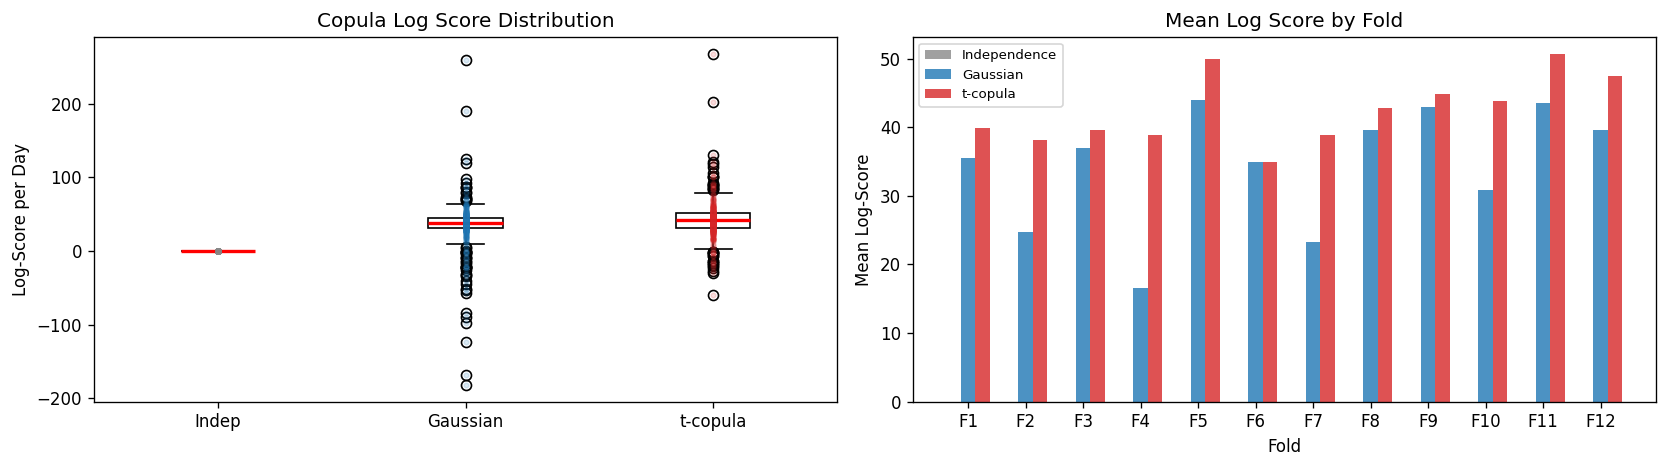

In [18]:
# ── Constants (model keys, labels, colours, pooled OOS PITs) ───────
MODELS       = ['P_indep', 'P_gauss', 'P_t']
MODEL_LABELS = ['Independence', 'Gaussian', 't-copula']
COLORS       = ['#888888', '#1f77b4', '#d62728']
U_all        = np.vstack([r['U_test'] for r in fold_results])   # (n_oos, 48)

# ── Copula Log Score ───────────────────────────────────────────────
from scipy.stats import ttest_rel

ll_indep_all = np.concatenate([r['ll_indep'] for r in fold_results])
ll_gauss_all = np.concatenate([r['ll_gauss'] for r in fold_results])
ll_t_all     = np.concatenate([r['ll_tcop']  for r in fold_results])

print('=== Copula Log Score (per day) ===')
for name, ll in [('Independence', ll_indep_all), ('Gaussian', ll_gauss_all), ('t-copula', ll_t_all)]:
    print(f'  {name:20s}: mean = {ll.mean():.3f}, std = {ll.std():.3f}')

t_stat, p_val = ttest_rel(ll_t_all, ll_gauss_all)
print(f'\nPaired t-test (t vs Gaussian): t={t_stat:.3f}, p={p_val:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
bp = ax.boxplot([ll_indep_all, ll_gauss_all, ll_t_all],
                labels=['Indep', 'Gaussian', 't-copula'],
                patch_artist=True,
                medianprops={'color': 'red', 'lw': 2})
for i, (ll, col) in enumerate(zip([ll_indep_all, ll_gauss_all, ll_t_all], COLORS), 1):
    bp['boxes'][i-1].set_facecolor('white')
    ax.scatter([i]*len(ll), ll, alpha=0.15, s=8, color=col, zorder=3)
ax.set_ylabel('Log-Score per Day')
ax.set_title('Copula Log Score Distribution')

ax = axes[1]
n_folds = len(fold_results)
x = np.arange(n_folds)
w = 0.25
for k, (key, label, col) in enumerate(zip(['ll_indep', 'll_gauss', 'll_tcop'], MODEL_LABELS, COLORS)):
    means = [r[key].mean() for r in fold_results]
    ax.bar(x + k*w, means, w, label=label, color=col, alpha=0.8)
ax.set_xlabel('Fold')
ax.set_ylabel('Mean Log-Score')
ax.set_title('Mean Log Score by Fold')
ax.set_xticks(x + w)
ax.set_xticklabels([f'F{i+1}' for i in range(n_folds)])
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Section 8: Dependence Preservation

Core question: does the copula reproduce cross-period structure that independence misses?
- Pairwise Spearman correlation matrices
- Tail co-exceedance probabilities
- Block dependence (early morning vs evening peak)


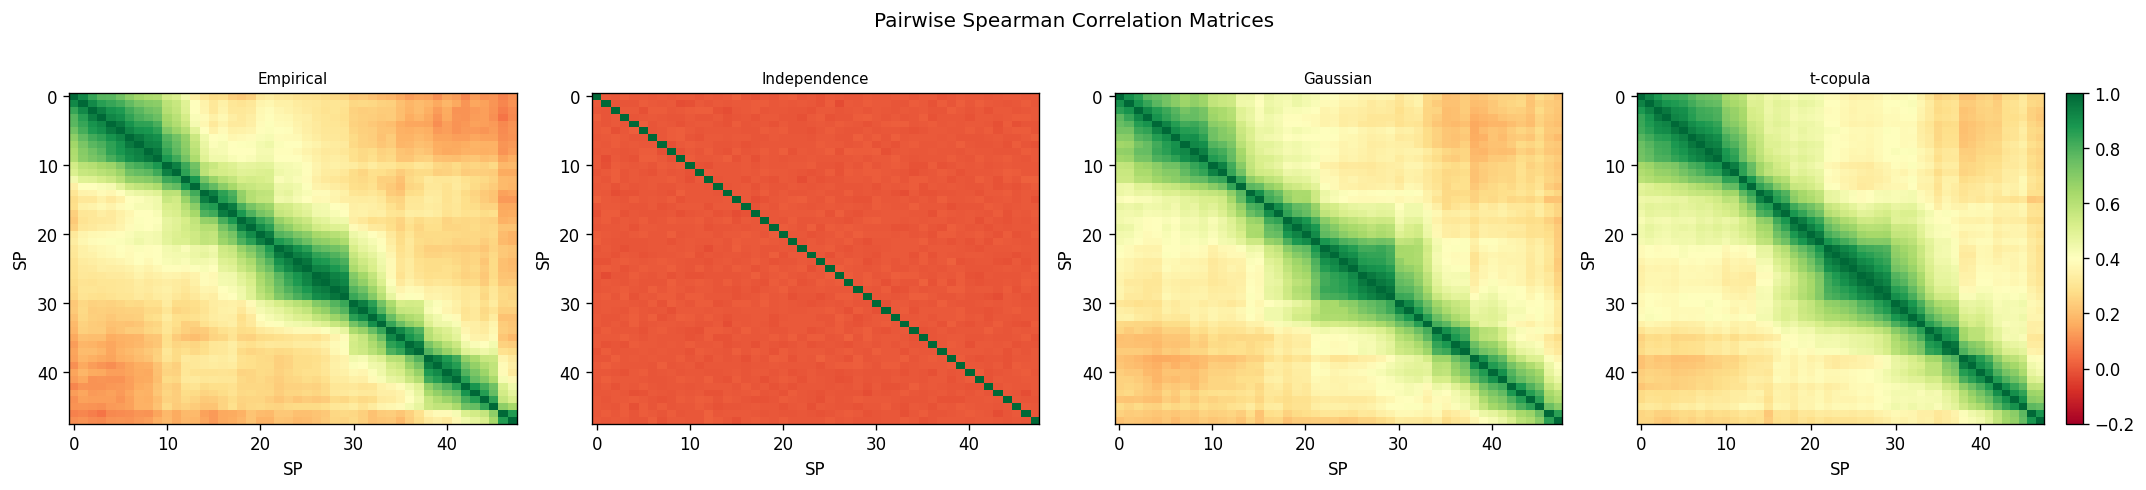


=== Spearman MAE by lag block ===
Block                         Independence      Gaussian      t-copula
Lag 1-2 (adjacent)                  0.8643        0.0236        0.0226
Lag 3-6                             0.6541        0.0363        0.0532
Lag 7-12                            0.4302        0.0652        0.0859
Lag 13+                             0.2594        0.0615        0.0945


In [ ]:
# ── Pairwise Spearman Correlation ──────────────────────────────────
rho_emp_mat, _ = spearmanr(U_all)
Rho_emp = rho_emp_mat  # (48, 48)

# Simulated: generate U samples from fitted copula parameters
N_SIM = 2000
U_sim = {m: [] for m in MODELS}

for r in fold_results:
    nu = r['nu_hat']
    Sg = r['Sigma_gauss']
    St = r['Sigma_t']
    U_sim['P_indep'].append(rng.uniform(0, 1, (N_SIM, 48)))
    Z_s = rng.multivariate_normal(np.zeros(48), Sg, size=N_SIM)
    U_sim['P_gauss'].append(norm.cdf(Z_s))
    z_t = rng.multivariate_normal(np.zeros(48), St, size=N_SIM)
    w   = rng.chisquare(nu, size=N_SIM) / nu
    x_t = z_t / np.sqrt(w[:, None])
    U_sim['P_t'].append(t_dist.cdf(x_t, df=nu))

Rho_sim = {}
for m in MODELS:
    U_pooled = np.vstack(U_sim[m])
    rho_s, _ = spearmanr(U_pooled)
    Rho_sim[m] = rho_s

# 4-panel heatmap
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
panels = [('Empirical', Rho_emp)] + [(l, Rho_sim[m]) for m, l in zip(MODELS, MODEL_LABELS)]
for ax, (title, R) in zip(axes, panels):
    im = ax.imshow(R, vmin=-0.2, vmax=1.0, cmap='RdYlGn', aspect='auto')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('SP')
    ax.set_ylabel('SP')
plt.colorbar(im, ax=axes[-1], fraction=0.04)
plt.suptitle('Pairwise Spearman Correlation Matrices', y=1.01)
plt.tight_layout()
plt.show()

def block_mae(R_true, R_pred, lag_lo, lag_hi):
    mask = np.zeros((48, 48), bool)
    for i in range(48):
        for j in range(48):
            lag = abs(i - j)
            if lag_lo <= lag <= lag_hi:
                mask[i, j] = True
    return np.abs(R_true[mask] - R_pred[mask]).mean()

print('\n=== Spearman MAE by lag block ===')
blocks = [('Lag 1-2 (adjacent)', 1, 2), ('Lag 3-6', 3, 6),
          ('Lag 7-12', 7, 12), ('Lag 13+', 13, 47)]
header = f"{'Block':28s}" + ''.join(f'{l:>14s}' for l in MODEL_LABELS)
print(header)
for bname, lo, hi in blocks:
    row = f'{bname:28s}'
    for m in MODELS:
        row += f'{block_mae(Rho_emp, Rho_sim[m], lo, hi):14.4f}'
    print(row)


The empirical data shows these cross-day-boundary correlations are near zero (orange), but both copulas predict them as noticeably positive (green). The copulas overestimate long-lag dependence.       

Both copulas use a single global correlation matrix Sigma estimated from the full training data. This is a stationary, unstructured parametrization — it has no concept of "early morning prices and late evening prices are from different regimes and don't move together." The fitted Sigma ends up pulling some positive correlation into those distant pairs, likely because the training data has days where overall price levels shift the whole day (e.g., high-demand days), which inflates long-lag correlations globally. Imposing a more structured correlation model (e.g., block-diagonal, or time-decay) could potentially fix this issue and better capture the true dependence structure.

In [ ]:
# ── Tail Co-exceedance ─────────────────────────────────────────────
TAIL_PAIRS_DEF = [
    ('Adjacent (1,2)',     0,  1),
    ('Adjacent (17,18)',  16, 17),
    ('4-apart (1,5)',      0,  4),
    ('4-apart (33,37)',   32, 36),
    ('Overnight->Evening', 3, 35),
    ('Overnight->Evening', 3, 37),
]

print('=== Tail Co-exceedance (10th/90th percentile) ===')
header = f"{'Pair':25s} {'Tail':8s}" + ''.join(f'{l:>14s}' for l in ['Empirical']+MODEL_LABELS)
print(header)

all_data = [('Empirical', U_all)] + [(l, np.vstack(U_sim[m])) for m, l in zip(MODELS, MODEL_LABELS)]

for pname, i, j in TAIL_PAIRS_DEF:
    for tail_name, lo, hi in [('Lower', 0.1, None), ('Upper', None, 0.9)]:
        row = f'{pname:25s} {tail_name:8s}'
        for src_name, U_src in all_data:
            ui, uj = U_src[:, i], U_src[:, j]
            if tail_name == 'Lower':
                prob = ((ui < lo) & (uj < lo)).mean()
            else:
                prob = ((ui > hi) & (uj > hi)).mean()
            row += f'{prob:14.4f}'
        print(row)


=== Tail Co-exceedance (10th/90th percentile) ===
Pair                      Tail         Empirical  Independence      Gaussian      t-copula
Adjacent (1,2)            Lower           0.0306        0.0106        0.0712        0.0772
Adjacent (1,2)            Upper           0.0444        0.0119        0.0710        0.0769
Adjacent (17,18)          Lower           0.0611        0.0090        0.0710        0.0745
Adjacent (17,18)          Upper           0.0722        0.0095        0.0716        0.0785
4-apart (1,5)             Lower           0.0306        0.0098        0.0534        0.0614
4-apart (1,5)             Upper           0.0361        0.0115        0.0536        0.0605
4-apart (33,37)           Lower           0.0528        0.0104        0.0428        0.0465
4-apart (33,37)           Upper           0.0528        0.0094        0.0420        0.0495
Overnight->Evening        Lower           0.0056        0.0105        0.0185        0.0217
Overnight->Evening        Upper         

The copulas systematically overestimate tail co-exceedance at all lags, just less badly for medium-range than for the extremes.

## Section 9: Derived Distribution Checks

In battery trading, spread is often more relevant than absolute price for risk management. We check if the copula models can capture these derived distributions. This is done by:
- compute the actual spread
- compute 500 simulated spreads, by taking the difference of the two pairs across all 500 simulated paths
- treat the 500 simulated spreads as a forecast distribution and score it with condinous ranked probability score (CRPS) via pinball loss 


In [ ]:
# ── Spread CRPS ──────────────────────────────────────────────────
SPREAD_PAIRS = [
    ('Adjacent (1,2)',     0,  1),
    ('Adjacent (17,18)',  16, 17),
    ('4-apart (1,5)',      0,  4),
    ('4-apart (33,37)',   32, 36),
    ('Overnight->Evening', 3, 35),
    ('Midday->Evening',   23, 35),
]

def pinball_loss(y, q_hat, alpha):
    err = y - q_hat
    return np.where(err >= 0, alpha * err, (alpha - 1) * err)

def crps_from_samples(actual_val, sim_samples, n_q=50):
    alphas = np.linspace(0.02, 0.98, n_q)
    qs = np.quantile(sim_samples, alphas)
    return 2 * np.mean([pinball_loss(actual_val, qs[k], alphas[k]) for k in range(n_q)])

crps_results = {m: {pname: [] for pname, _, _ in SPREAD_PAIRS} for m in MODELS}
spread_pit   = {m: {pname: [] for pname, _, _ in SPREAD_PAIRS} for m in MODELS}

for fold_i, day_list in enumerate(fold_scenarios):
    for ds in day_list:
        actual = ds['actual']
        for pname, i, j in SPREAD_PAIRS:
            actual_spread = actual[j] - actual[i]
            if np.isnan(actual_spread):
                continue
            for m in MODELS:
                P = ds[m]
                sim_spread = P[:, j] - P[:, i]
                crps_results[m][pname].append(crps_from_samples(actual_spread, sim_spread))
                spread_pit[m][pname].append((sim_spread <= actual_spread).mean())

print('=== Spread CRPS by Pair ===')
header = f"{'Pair':22s}" + ''.join(f'{l:>14s}' for l in MODEL_LABELS)
print(header)
for pname, _, _ in SPREAD_PAIRS:
    row = f'{pname:22s}'
    for m in MODELS:
        row += f'{np.mean(crps_results[m][pname]):14.3f}'
    print(row)



=== Spread CRPS by Pair ===
Pair                    Independence      Gaussian      t-copula
Adjacent (1,2)                 6.036         2.673         2.505
Adjacent (17,18)               6.578         2.835         2.652
4-apart (1,5)                  6.964         4.946         4.788
4-apart (33,37)               10.011         9.154         9.064
Overnight->Evening            12.535        12.330        12.231
Midday->Evening               13.418        13.286        13.173


Both copulas perform significantly better than independence at closer range. For longer range the performance degrades and becomes comparable to independence, which is consistent with the correlation and tail dependence diagnostics showing the copulas struggle to capture long-range dependence. There's room for improvement especially in capturing the long-range dependence that affects spread distributions at longer lags.

## Conclusion

### Key findings

**Setup**: 12 rolling OOS folds (Feb 2025 – Feb 2026), 360 test days total, ν ≈ 27–32 across folds.

1. **Multivariate calibration**: Log scores confirm the hierarchy Independence (0.0) << Gaussian (34.4) < t-copula (42.5) per day on average. The t-copula advantage is highly significant: paired t-test t=7.19, p<0.0001. The t-copula also shows lower variance (std 26.5 vs 33.6 for Gaussian), meaning it is more consistent across days.

2. **Dependence preservation**: Independence fails catastrophically at adjacent lags (Spearman MAE 0.86), while both copulas are accurate (Gaussian 0.024, t-copula 0.023). At longer lags (13+), copulas still outperform independence (MAE ~0.06 vs 0.26), though they overestimate long-range dependence (t-copula MAE > Gaussian at lags 7+). Tail co-exceedance follows the same pattern: copulas overestimate joint tail probabilities at all lags, with the overestimation most pronounced for distant period pairs (Overnight→Evening), where even independence is closer to the near-zero empirical values.

3. **Spread CRPS**: For adjacent spreads, independence CRPS is 6.0–6.6 vs 2.5–2.7 for the copulas — a ~56% reduction. For distant pairs (Overnight→Evening, Midday→Evening) the gain shrinks to near zero, consistent with both copulas overestimating long-range dependence.